# Using Ragas to Evaluate a RAG Application built with LangChain and LangGraph

In the following notebook, we'll be looking at how [Ragas](https://github.com/explodinggradients/ragas) can be helpful in a number of ways when looking to evaluate your RAG applications!

While this example is rooted in LangChain/LangGraph - Ragas is framework agnostic (you don't even need to be using a framework!).

- 🤝 Breakout Room #1
  1. Task 1: Installing Required Libraries
  2. Task 2: Set Environment Variables
  3. Task 3: Synthetic Dataset Generation for Evaluation using Ragas
  4. Task 4: Evaluating our Pipeline with Ragas
  5. Task 6: Making Adjustments and Re-Evaluating

But first! Let's set some dependencies!

## Dependencies and API Keys:

We'll also need to provide our API keys.

First, OpenAI's for our LLM/embedding model combination!

In [2]:
import os
from dotenv import load_dotenv
from uuid import uuid4

from pathlib import Path
env_path = Path('.') / '.env'
load_dotenv(dotenv_path=env_path)

# Set the environment variable explicitly
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

# Verify it's loaded
print("API Key loaded:", bool(os.getenv("OPENAI_API_KEY")))

API Key loaded: True


## Generating Synthetic Test Data

We wil be using Ragas to build out a set of synthetic test questions, references, and reference contexts. This is useful because it will allow us to find out how our system is performing.

> NOTE: Ragas is best suited for finding *directional* changes in your LLM-based systems. The absolute scores aren't comparable in a vacuum.

### Data Preparation

We'll prepare our data - which should hopefull be familiar at this point since it's our Loan Data use-case!

Next, let's load our data into a familiar LangChain format using the `DirectoryLoader`.

In [7]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader


path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

### Knowledge Graph Based Synthetic Generation

Ragas uses a knowledge graph based approach to create data. This is extremely useful as it allows us to create complex queries rather simply. The additional testset complexity allows us to evaluate larger problems more effectively, as systems tend to be very strong on simple evaluation tasks.

Let's start by defining our `generator_llm` (which will generate our questions, summaries, and more), and our `generator_embeddings` which will be useful in building our graph.

### Abstracted SDG

The above method is the full process - but we can shortcut that using the provided abstractions!

This will generate our knowledge graph under the hood, and will - from there - generate our personas and scenarios to construct our queries.



In [27]:
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
generator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1"))
generator_embeddings = LangchainEmbeddingsWrapper(OpenAIEmbeddings())

In [28]:
from ragas.testset import TestsetGenerator

generator = TestsetGenerator(llm=generator_llm, embedding_model=generator_embeddings)
dataset = generator.generate_with_langchain_docs(docs, testset_size=10)

Applying HeadlinesExtractor:   0%|          | 0/21 [00:00<?, ?it/s]

Applying HeadlineSplitter:   0%|          | 0/64 [00:00<?, ?it/s]

unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to apply transformation: 'headlines' property not found in this node
unable to ap

Applying SummaryExtractor:   0%|          | 0/38 [00:00<?, ?it/s]

Property 'summary' already exists in node '1d6bef'. Skipping!
Property 'summary' already exists in node '0eff84'. Skipping!
Property 'summary' already exists in node 'bfb0ce'. Skipping!
Property 'summary' already exists in node '835e9e'. Skipping!
Property 'summary' already exists in node 'e10e9c'. Skipping!
Property 'summary' already exists in node '4365ee'. Skipping!
Property 'summary' already exists in node '392cd7'. Skipping!
Property 'summary' already exists in node 'ed654c'. Skipping!
Property 'summary' already exists in node '852538'. Skipping!
Property 'summary' already exists in node '1a6dd8'. Skipping!
Property 'summary' already exists in node 'b26dcc'. Skipping!
Property 'summary' already exists in node 'b4ff3d'. Skipping!
Property 'summary' already exists in node '2916ae'. Skipping!
Property 'summary' already exists in node '1a7562'. Skipping!
Property 'summary' already exists in node '802e02'. Skipping!
Property 'summary' already exists in node '000674'. Skipping!
Property

...

Property 'summary_embedding' already exists in node '0eff84'. Skipping!
Property 'summary_embedding' already exists in node 'bfb0ce'. Skipping!
Property 'summary_embedding' already exists in node 'b4ff3d'. Skipping!
Property 'summary_embedding' already exists in node '1a6dd8'. Skipping!
Property 'summary_embedding' already exists in node '1d6bef'. Skipping!
Property 'summary_embedding' already exists in node 'e10e9c'. Skipping!
Property 'summary_embedding' already exists in node 'ed654c'. Skipping!
Property 'summary_embedding' already exists in node '852538'. Skipping!
Property 'summary_embedding' already exists in node '4365ee'. Skipping!
Property 'summary_embedding' already exists in node '802e02'. Skipping!
Property 'summary_embedding' already exists in node '0951be'. Skipping!
Property 'summary_embedding' already exists in node 'b26dcc'. Skipping!
Property 'summary_embedding' already exists in node '1a7562'. Skipping!
Property 'summary_embedding' already exists in node '835e9e'. Sk

Applying [CosineSimilarityBuilder, OverlapScoreBuilder]:   0%|          | 0/2 [00:00<?, ?it/s]

Generating personas:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Scenarios:   0%|          | 0/3 [00:00<?, ?it/s]

Generating Samples:   0%|          | 0/10 [00:00<?, ?it/s]

In [30]:
dataset.to_pandas()

,user_input,reference_contexts,reference,synthesizer_name
0,how chatgpt get so many people use it so fast ...,[Introduction ChatGPT launched in November 202...,chatgpt launched in november 2022 and by july ...,single_hop_specifc_query_synthesizer
1,What was the total number of messages in Jun 2...,[Month Non-Work (M) (%) Work (M) (%) Total Mes...,The total number of messages in Jun 2025 was 2...,single_hop_specifc_query_synthesizer
2,Where can I find more details about the sampli...,[Table 1: ChatGPT daily message counts (millio...,Details about the sampling exclusions—such as ...,single_hop_specifc_query_synthesizer
3,"According to the provided context, what occupa...",[Variation by Occupation Figure 23 presents va...,SOC2 code 11 refers to management and business...,single_hop_specifc_query_synthesizer
4,How has the growth in ChatGPT message volume b...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,"Between June 2024 and June 2025, ChatGPT's tot...",multi_hop_abstract_query_synthesizer
5,Based on the provided message volume statistic...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,"Between June 2024 and June 2025, ChatGPT's tot...",multi_hop_abstract_query_synthesizer
6,Based on the message volume statistics for Cha...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,"Between June 2024 and June 2025, ChatGPT's tot...",multi_hop_abstract_query_synthesizer
7,Based on the provided message volume statistic...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,"Between June 2024 and June 2025, the total dai...",multi_hop_abstract_query_synthesizer
8,How did the proportion and volume of non-work ...,[<1-hop>\n\nConclusion This paper studies the ...,"Between Jun 2024 and Jun 2025, the number of n...",multi_hop_specific_query_synthesizer
9,"Accrding to Collis and Brynjolfsson, how has t...",[<1-hop>\n\nConclusion This paper studies the ...,"Collis and Brynjolfsson (2025) document that, ...",multi_hop_specific_query_synthesizer


## LangChain RAG

Now we'll construct our LangChain RAG, which we will be evaluating using the above created test data!

### R - Retrieval

Let's start with building our retrieval pipeline, which will involve loading the same data we used to create our synthetic test set above.

> NOTE: We need to use the same data - as our test set is specifically designed for this data.

In [10]:
path = "data/"
loader = DirectoryLoader(path, glob="*.pdf", loader_cls=PyMuPDFLoader)
docs = loader.load()

In [9]:
len(docs)

64

Now that we have our data loaded, let's split it into chunks!

In [10]:
from langchain.text_splitter import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=50, chunk_overlap=0)
split_documents = text_splitter.split_documents(docs)
len(split_documents)

3122

#### ❓ Question: 

What is the purpose of the `chunk_overlap` parameter in the `RecursiveCharacterTextSplitter`?

Next up, we'll need to provide an embedding model that we can use to construct our vector store.

In [11]:
from langchain_openai import OpenAIEmbeddings

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

Now we can build our in memory QDrant vector store.

In [12]:
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="use_case_data",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="use_case_data",
    embedding=embeddings,
)

We can now add our documents to our vector store.

In [13]:
_ = vector_store.add_documents(documents=split_documents)

Let's define our retriever.

In [14]:
retriever = vector_store.as_retriever(search_kwargs={"k": 3})

Now we can produce a node for retrieval!

In [15]:
def retrieve(state):
  retrieved_docs = retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

### Augmented

Let's create a simple RAG prompt!

In [21]:
from langchain.prompts import ChatPromptTemplate

RAG_PROMPT = """\
You are a helpful assistant who answers questions based on provided context. You must only use the provided context, and cannot use your own knowledge.

### Question
{question}

### Context
{context}
"""

rag_prompt = ChatPromptTemplate.from_template(RAG_PROMPT)

### Generation

We'll also need an LLM to generate responses - we'll use `gpt-4o-nano` to avoid using the same model as our judge model.

In [23]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4.1-nano")

Then we can create a `generate` node!

In [18]:
def generate(state):
  docs_content = "\n\n".join(doc.page_content for doc in state["context"])
  messages = rag_prompt.format_messages(question=state["question"], context=docs_content)
  response = llm.invoke(messages)
  return {"response" : response.content}

### Building RAG Graph with LangGraph

Let's create some state for our LangGraph RAG graph!

In [19]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document

class State(TypedDict):
  question: str
  context: List[Document]
  response: str

Now we can build our simple graph!

> NOTE: We're using `add_sequence` since we will always move from retrieval to generation. This is essentially building a chain in LangGraph.

In [20]:
graph_builder = StateGraph(State).add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
graph = graph_builder.compile()

Let's do a test to make sure it's doing what we'd expect.

In [21]:
response = graph.invoke({"question" : "What are the different kinds of loans?"})

In [22]:
response["response"]

'The provided context does not include information about the different kinds of loans.'

## Evaluating the App with Ragas

Now we can finally do our evaluation!

We'll start by running the queries we generated usign SDG above through our application to get context and responses.

In [23]:
for test_row in dataset:
  response = graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]

In [24]:
dataset.samples[0].eval_sample.response

'Bick et al. (2024) reported that ChatGPT usage has grown rapidly.'

Then we can convert that table into a `EvaluationDataset` which will make the process of evaluation smoother.

In [25]:
from ragas import EvaluationDataset

evaluation_dataset = EvaluationDataset.from_pandas(dataset.to_pandas())

We'll need to select a judge model - in this case we're using the same model that was used to generate our Synthetic Data.

In [26]:
from ragas import evaluate
from ragas.llms import LangchainLLMWrapper

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))

Next up - we simply evaluate on our desired metrics!

In [27]:
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness, ResponseRelevancy, ContextEntityRecall, NoiseSensitivity
from ragas import evaluate, RunConfig

custom_run_config = RunConfig(timeout=360)

baseline_result = evaluate(
    dataset=evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
baseline_result

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

{'context_recall': 0.0000, 'faithfulness': 0.5794, 'factual_correctness': 0.3250, 'answer_relevancy': 0.2885, 'context_entity_recall': 0.1009, 'noise_sensitivity_relevant': 0.0000}

## Making Adjustments and Re-Evaluating

Now that we've got our baseline - let's make a change and see how the model improves or doesn't improve!

> NOTE: This will be using Cohere's Rerank model - please be sure to [sign-up for an API key!](https://docs.cohere.com/reference/about)

In [44]:
os.environ["COHERE_API_KEY"] = os.getenv("COHERE_API_KEY")
print("API Key loaded:", bool(os.getenv("COHERE_API_KEY")))

API Key loaded: True



We'll first set our retriever to return more documents, which will allow us to take advantage of the reranking.

In [45]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=30)
split_documents = text_splitter.split_documents(docs)
len(split_documents)

embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

client = QdrantClient(":memory:")

client.create_collection(
    collection_name="use_case_data_new_chunks",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="use_case_data_new_chunks",
    embedding=embeddings,
)

_ = vector_store.add_documents(documents=split_documents)

adjusted_example_retriever = vector_store.as_retriever(search_kwargs={"k": 20})

Reranking, or contextual compression, is a technique that uses a reranker to compress the retrieved documents into a smaller set of documents.

This is essentially a slower, more accurate form of semantic similarity that we use on a smaller subset of our documents.

In [46]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

def retrieve_adjusted(state):
  compressor = CohereRerank(model="rerank-v3.5")
  compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=adjusted_example_retriever, search_kwargs={"k": 5}
  )
  retrieved_docs = compression_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

We can simply rebuild our graph with the new retriever!

In [47]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document



class AdjustedState(TypedDict):
  question: str
  context: List[Document]
  response: str

adjusted_graph_builder = StateGraph(AdjustedState).add_sequence([retrieve_adjusted, generate])
adjusted_graph_builder.add_edge(START, "retrieve_adjusted")
adjusted_graph = adjusted_graph_builder.compile()

In [48]:
response = adjusted_graph.invoke({"question" : "What are the different kinds of loans?"})
response["response"]

'The provided context does not include information about the different kinds of loans.'

In [50]:
import time
import copy

rerank_dataset = copy.deepcopy(dataset)

for test_row in rerank_dataset:
  response = adjusted_graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]
  time.sleep(2) # To try to avoid rate limiting.

In [ ]:
rerank_dataset.samples[0].eval_sample.response

'ChatGPT has gained so many users quickly due to its broad appeal and increasing adoption worldwide, especially in low- and middle-income countries where growth rates are higher. Its rapid growth is also supported by early adopters initially being disproportionately male, but this gender gap has since narrowed, leading to a more diverse user base.\n\nPeople use ChatGPT for a variety of purposes. While about 70% of user queries as of July 2025 are unrelated to work, many also use it for work-related tasks. Higher-educated users working in professional occupations tend to use ChatGPT more for work-related messages and for asking questions rather than performing tasks at work. Overall, users engage in both work and non-work activities, with non-work-related usage increasing faster over time.\n\nRegarding how ChatGPT figures out what people talk about without observing messages directly, the system employs a privacy-preserving automated pipeline. This method classifies usage patterns withi

In [ ]:
from ragas import EvaluationDataset
rerank_evaluation_dataset = EvaluationDataset.from_pandas(rerank_dataset.to_pandas())

In [ ]:
from ragas import evaluate,  RunConfig
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness, ResponseRelevancy, ContextEntityRecall, NoiseSensitivity
from ragas.llms import LangchainLLMWrapper

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))
custom_run_config = RunConfig(timeout=360)

rerank_result = evaluate(
    dataset=rerank_evaluation_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
rerank_result

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

Exception raised in Job[59]: AttributeError('StringIO' object has no attribute 'statements')


{'context_recall': 0.8250, 'faithfulness': 0.9340, 'factual_correctness': 0.6210, 'answer_relevancy': 0.9426, 'context_entity_recall': 0.3603, 'noise_sensitivity_relevant': 0.2599}

#### ❓ Question: 

Which system performed better, on what metrics, and why?

**Performance Comparison**

Context Recall: 0.0000 → 0.8250 (+82.5 percentage points)

Faithfulness: 0.5794 → 0.9340 (+35.46 percentage points)

Answer Relevancy: 0.2885 → 0.9426 (+65.41 percentage points)

Factual Correctness: 0.3250 → 0.6210 (+29.6 percentage points)

Context Entity Recall: 0.1009 → 0.3603 (+25.94 percentage points)

Noise Sensitivity: 0.0000 → 0.2599 (100%)

Why?

Better Chunking Strategy: Increased chunk size from 50 to 500 characters, plus overlap. This provides more context per chunk and reduces information fragmentation

Reranking with Cohere: This dramatically improved the quality of retrieved context. By first retrieving 20 and then compressiong to 5 via rerank. 

More Comprehensive Retrieval: Increased initial retrieval from 3 to 20 documents. Then compressed to the most relevant 5 using reranking. This approach casts a wider net while maintaining precision

The most striking improvement in Context Recall (0% → 82.5%) indicates that the reranked system now successfully retrieves relevant information that the baseline system was completely missing. This fundamental improvement cascaded to better faithfulness, relevancy, and factual correctness as the system now had access to the right information to generate accurate responses.







## One more enhancement: Semantic chunking

In [57]:
from langchain.text_splitter import RecursiveCharacterTextSplitter
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper
from langchain_openai import ChatOpenAI
from langchain_openai import OpenAIEmbeddings
from langchain_qdrant import QdrantVectorStore
from qdrant_client import QdrantClient
from qdrant_client.http.models import Distance, VectorParams
from langchain_experimental.text_splitter import SemanticChunker


embeddings = OpenAIEmbeddings(model="text-embedding-3-small")
semantic_splitter = SemanticChunker(
    embeddings=embeddings,
    breakpoint_threshold_type="percentile",  # or "standard_deviation"
    breakpoint_threshold_amount=95,  # percentile to split at
    min_chunk_size=500
)
split_documents = semantic_splitter.split_documents(docs)
len(split_documents)


client = QdrantClient(":memory:")

client.create_collection(
    collection_name="use_case_data_semantic_chunks",
    vectors_config=VectorParams(size=1536, distance=Distance.COSINE),
)

vector_store = QdrantVectorStore(
    client=client,
    collection_name="use_case_data_semantic_chunks",
    embedding=embeddings,
)

_ = vector_store.add_documents(documents=split_documents)

semantic_retriever = vector_store.as_retriever(search_kwargs={"k": 20})

In [60]:
len(split_documents)

106

In [62]:
from langchain.retrievers.contextual_compression import ContextualCompressionRetriever
from langchain_cohere import CohereRerank

def retrieve_semantic(state):
  compressor = CohereRerank(model="rerank-v3.5")
  compression_retriever = ContextualCompressionRetriever(
    base_compressor=compressor, base_retriever=semantic_retriever, search_kwargs={"k": 5}
  )
  retrieved_docs = compression_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

In [65]:
from langgraph.graph import START, StateGraph
from typing_extensions import List, TypedDict
from langchain_core.documents import Document



class SemanticState(TypedDict):
  question: str
  context: List[Document]
  response: str

semantic_graph_builder = StateGraph(SemanticState).add_sequence([retrieve_semantic, generate])
semantic_graph_builder.add_edge(START, "retrieve_semantic")
semantic_graph = semantic_graph_builder.compile()

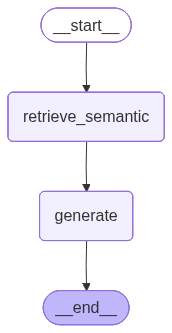

In [66]:
semantic_graph

In [67]:
response = semantic_graph.invoke({"question" : "What are the different kinds of loans?"})
response["response"]

'The provided context does not specify the different kinds of loans.'

In [68]:
import time
import copy

rerank_semantic_dataset = copy.deepcopy(dataset)

for test_row in rerank_semantic_dataset:
  response = semantic_graph.invoke({"question" : test_row.eval_sample.user_input})
  test_row.eval_sample.response = response["response"]
  test_row.eval_sample.retrieved_contexts = [context.page_content for context in response["context"]]
  time.sleep(2) # To try to avoid rate limiting.

In [72]:
rerank_semantic_dataset.samples[0].eval_sample.response

"ChatGPT was able to get so many people to use it so quickly because of its rapid global adoption, reaching around 10% of the world's adult population by July 2025 with 18 billion messages sent each week. The widespread growth was driven by its accessibility as a consumer product, and early adopters included a broad demographic range, with the gender gap narrowing over time and higher growth rates in lower-income countries.\n\nPeople use ChatGPT for various purposes, both for work and non-work activities. While the growth in non-work-related messages has been faster, about 70% of the usage by July 2025 was unrelated to work. Common conversation topics include Practical Guidance, Seeking Information, and Writing, which together account for nearly 80% of all conversations. Writing is the most dominant activity within work-related messages, especially among users in management and business occupations, where more than half of work messages involve modifying or creating text rather than ge

In [73]:
from ragas import EvaluationDataset
rerank_semantic_dataset = EvaluationDataset.from_pandas(rerank_semantic_dataset.to_pandas())

In [75]:
rerank_semantic_dataset.to_pandas()

,user_input,retrieved_contexts,reference_contexts,response,reference
0,how chatgpt get so many people use it so fast ...,"[How People Use ChatGPT\nAaron Chatterji, Thom...",[Introduction ChatGPT launched in November 202...,ChatGPT was able to get so many people to use ...,chatgpt launched in november 2022 and by july ...
1,What was the total number of messages in Jun 2...,[Month\nNon-Work (M)\n(%)\nWork (M)\n(%)\nTota...,[Month Non-Work (M) (%) Work (M) (%) Total Mes...,The total number of messages in June 2025 was ...,The total number of messages in Jun 2025 was 2...
2,Where can I find more details about the sampli...,[The\nclassifiers are introduced in more detai...,[Table 1: ChatGPT daily message counts (millio...,You can find more details about the sampling e...,Details about the sampling exclusions—such as ...
3,"According to the provided context, what occupa...",[6.5\nVariation by Occupation\nFigure 23 prese...,[Variation by Occupation Figure 23 presents va...,"According to the provided context, occupations...",SOC2 code 11 refers to management and business...
4,How has the growth in ChatGPT message volume b...,[Month\nNon-Work (M)\n(%)\nWork (M)\n(%)\nTota...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,The growth in ChatGPT message volume between J...,"Between June 2024 and June 2025, ChatGPT's tot..."
5,Based on the provided message volume statistic...,[Month\nNon-Work (M)\n(%)\nWork (M)\n(%)\nTota...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,The data indicates that from June 2024 to June...,"Between June 2024 and June 2025, ChatGPT's tot..."
6,Based on the message volume statistics for Cha...,[Month\nNon-Work (M)\n(%)\nWork (M)\n(%)\nTota...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,The message volume statistics for ChatGPT betw...,"Between June 2024 and June 2025, ChatGPT's tot..."
7,Based on the provided message volume statistic...,[Month\nNon-Work (M)\n(%)\nWork (M)\n(%)\nTota...,[<1-hop>\n\nMonth Non-Work (M) (%) Work (M) (%...,"From June 2024 to June 2025, the total ChatGPT...","Between June 2024 and June 2025, the total dai..."
8,How did the proportion and volume of non-work ...,[This paper documents eight important facts ab...,[<1-hop>\n\nConclusion This paper studies the ...,"From June 2024 to July 2025, the proportion of...","Between Jun 2024 and Jun 2025, the number of n..."
9,"Accrding to Collis and Brynjolfsson, how has t...",[Month\nNon-Work (M)\n(%)\nWork (M)\n(%)\nTota...,[<1-hop>\n\nConclusion This paper studies the ...,"According to Collis and Brynjolfsson (2025), t...","Collis and Brynjolfsson (2025) document that, ..."


In [76]:
from ragas import evaluate,  RunConfig
from ragas.metrics import LLMContextRecall, Faithfulness, FactualCorrectness, ResponseRelevancy, ContextEntityRecall, NoiseSensitivity
from ragas.llms import LangchainLLMWrapper

evaluator_llm = LangchainLLMWrapper(ChatOpenAI(model="gpt-4.1-mini"))
custom_run_config = RunConfig(timeout=360)

rerank_result = evaluate(
    dataset=rerank_semantic_dataset,
    metrics=[LLMContextRecall(), Faithfulness(), FactualCorrectness(), ResponseRelevancy(), ContextEntityRecall(), NoiseSensitivity()],
    llm=evaluator_llm,
    run_config=custom_run_config
)
rerank_result

Evaluating:   0%|          | 0/60 [00:00<?, ?it/s]

{'context_recall': 0.9550, 'faithfulness': 0.9575, 'factual_correctness': 0.6030, 'answer_relevancy': 0.9567, 'context_entity_recall': 0.2851, 'noise_sensitivity_relevant': 0.2992}

**Dramatic improvement in Context Recall: 0% → 82.5% → 95.5%. While it improved in other areas but teh gain was not substantial. But recall at 95% itself is a big improvement and worth considering.**

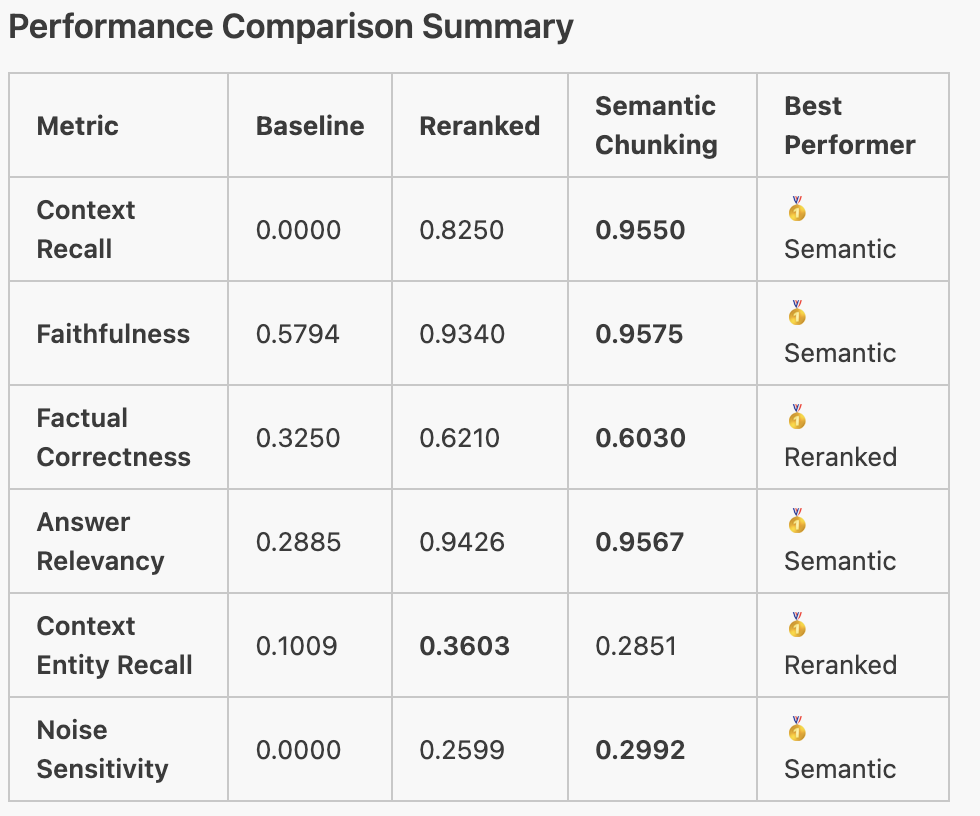

In [81]:
from IPython.display import Image, display

display(Image('data/performance.png'))

Performance Trends:

Baseline → Reranked: Massive improvement across all metrics

Reranked → Semantic: Further refinement, especially in recall and faithfulness

Trade-off: Semantic chunking slightly sacrifices factual accuracy for better context understanding